In [20]:
# Ячейка 1: Импорты и конфигурация
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import os
import random
from scipy.ndimage import gaussian_filter, median_filter
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric
import torch.utils.checkpoint as checkpoint_grad
import torch.nn.functional as F
from olimp.dataset.olimp import olimp
from olimp.dataset import read_img_path

# --- Конфигурация ---
IMG_SIZE    = 512
SIGMA_NOISE = 0.008
TRAIN_RATIO = 0.85

# Память: на 2 GPU по ~11GB
# base_ch=32 + batch=4 + grad_checkpoint = безопасно
BATCH_SIZE  = 4       # суммарный на 2 GPU (по 2 на каждом)
NUM_EPOCHS  = 60
LR          = 1e-4

# Используем оба GPU
GPU_IDS     = [0, 1]
DEVICE      = torch.device(f"cuda:{GPU_IDS[0]}")
USE_MULTI_GPU = torch.cuda.is_available() and torch.cuda.device_count() >= 2

SAVE_PATH   = "18KFbest_model.pt"

# Веса лоссов
W_L1    = 1.0
W_GRAD  = 0.5
W_FREQ  = 0.3
W_PHYS  = 0.5
W_REAL  = 20.0

# Gradient accumulation (эмулируем большой батч при малой памяти)
ACCUM_STEPS = 2   # реальный эффективный батч = BATCH_SIZE * ACCUM_STEPS

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print(f"Доступно GPU: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    mem   = torch.cuda.mem_get_info(i)
    print(f"  GPU {i}: {props.name} | "
          f"Total: {props.total_memory/1e9:.1f}GB | "
          f"Free: {mem[0]/1e9:.1f}GB")
print(f"Основное устройство: {DEVICE}")
print(f"Multi-GPU: {USE_MULTI_GPU} (GPU ids: {GPU_IDS})")
print(f"Effective batch size: {BATCH_SIZE * ACCUM_STEPS}")

Доступно GPU: 2
  GPU 0: NVIDIA GeForce GTX 1080 Ti | Total: 11.7GB | Free: 10.9GB
  GPU 1: NVIDIA GeForce GTX 1080 Ti | Total: 11.7GB | Free: 11.4GB
Основное устройство: cuda:0
Multi-GPU: True (GPU ids: [0, 1])
Effective batch size: 8


In [2]:
# Ячейка 2: Загрузка путей датасета
CATEGORIES = [
    'abstracts and textures', 'abstracts and textures/abstract art',
    'abstracts and textures/backgrounds and patterns',
    'abstracts and textures/colorful abstracts',
    'abstracts and textures/geometric shapes',
    'abstracts and textures/neon abstracts', 'abstracts and textures/textures',
    'animals', 'animals/birds', 'animals/farm animals',
    'animals/insects and spiders', 'animals/marine life', 'animals/pets',
    'animals/wild animals', 'art and culture',
    'art and culture/cartoon and comics',
    'art and culture/crafts and handicrafts',
    'art and culture/dance and theater performances',
    'art and culture/music concerts and instruments',
    'art and culture/painting and frescoes',
    'art and culture/sculpture and bas-reliefs', 'food and drinks',
    'food and drinks/desserts and bakery', 'food and drinks/dishes',
    'food and drinks/drinks',
    'food and drinks/food products on store shelves',
    'food and drinks/fruits and vegetables', 'food and drinks/street food',
    'interiors', 'interiors/gyms and pools', 'interiors/living spaces',
    'interiors/museums and galleries', 'interiors/offices',
    'interiors/restaurants and cafes',
    'interiors/shopping centers and stores', 'nature', 'nature/beaches',
    'nature/deserts', 'nature/fields and meadows', 'nature/forest',
    'nature/mountains', 'nature/water bodies', 'objects and items',
    'objects and items/books and stationery',
    'objects and items/clothing and accessories',
    'objects and items/electronics and gadgets',
    'objects and items/furniture and decor',
    'objects and items/tools and equipment',
    'objects and items/toys and games', 'portraits and people',
    'portraits and people/athletes and dancers',
    'portraits and people/crowds and demonstrations',
    'portraits and people/group photos',
    'portraits and people/individual portraits',
    'portraits and people/models on runway',
    'portraits and people/workers in their workplaces',
    'sports and active leisure',
    'sports and active leisure/cycling and rollerblading',
    'sports and active leisure/extreme sports',
    'sports and active leisure/individual sports',
    'sports and active leisure/martial arts',
    'sports and active leisure/team sports',
    'sports and active leisure/tourism and hikes', 'text and pictogram',
    'text and pictogram/billboard text', 'text and pictogram/blueprints',
    'text and pictogram/caricatures and pencil drawing',
    'text and pictogram/text documents', 'text and pictogram/traffic signs',
    'urban scenes', 'urban scenes/architecture',
    'urban scenes/city at night', 'urban scenes/graffiti and street art',
    'urban scenes/parks and squares', 'urban scenes/streets and avenues',
    'urban scenes/transport',
]

all_paths = []
for cat in CATEGORIES:
    try:
        ds = olimp(categories={cat})
        paths = ds[cat]
        all_paths.extend(paths)
    except Exception as e:
        print(f"  {cat}: пропущено ({e})")

rng_loader = np.random.default_rng(42)
rng_loader.shuffle(all_paths)
all_paths = all_paths[:3000]

n_train = int(TRAIN_RATIO * len(all_paths))
train_paths = all_paths[:n_train]
val_paths   = all_paths[n_train:]
print(f"Загружено: {len(all_paths)} | Train: {len(train_paths)} | Val: {len(val_paths)}")

/home/user/.local/lib/python3.10/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Загружено: 2620 | Train: 2227 | Val: 393


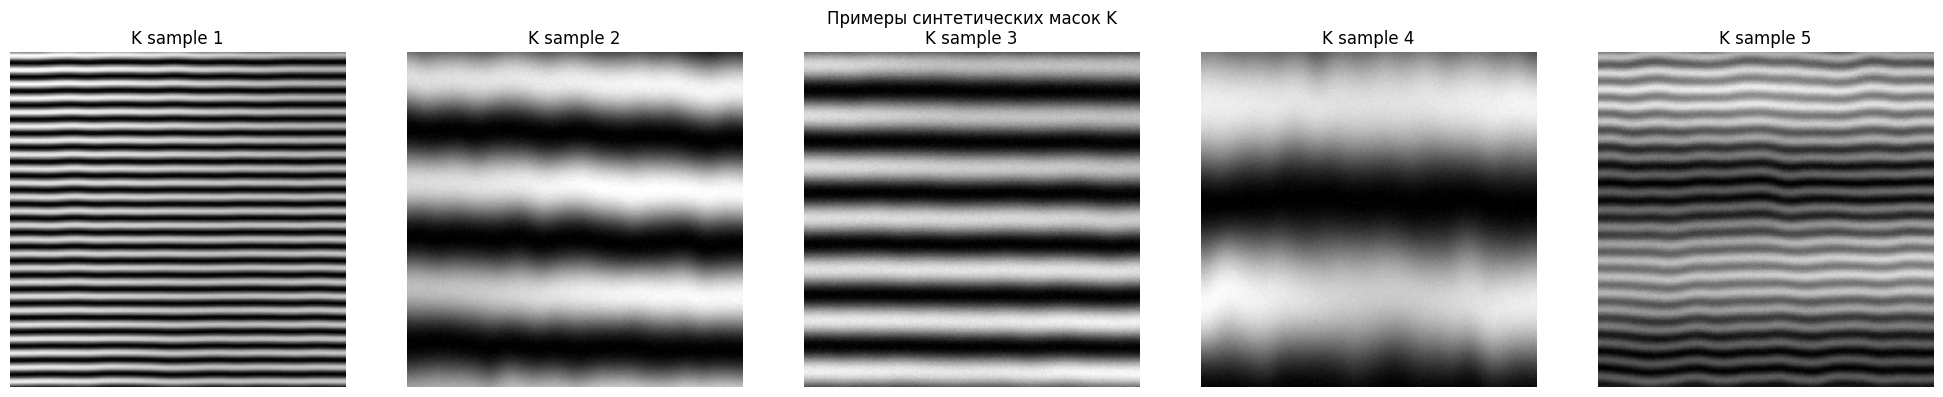

In [3]:
# Ячейка 3: Генерация синтетических масок K

_cfg_rng = np.random.default_rng(0)


def stripe_filter_smooth(h, w, T0=15, angle_deg=0.0, strength=0.7,
                         warp_amp=8.0, noise_sigma=0.02, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    y = np.arange(h, dtype=np.float32)
    x = np.arange(w, dtype=np.float32)
    X, Y = np.meshgrid(x, y)
    theta = np.deg2rad(angle_deg)
    U = -X * np.sin(theta) + Y * np.cos(theta)

    warp = gaussian_filter(
        rng.standard_normal((h, w)).astype(np.float32),
        sigma=[h / 8, w / 32]
    )
    warp = warp / (np.abs(warp).max() + 1e-8) * warp_amp * strength

    phase = (U + warp) / T0
    K = 0.5 + 0.5 * np.sin(2 * np.pi * phase)

    amp_map = gaussian_filter(
        rng.standard_normal((h, w)).astype(np.float32),
        sigma=[h / 4, w / 4]
    )
    amp_map = (0.7 + 0.3 * (amp_map - amp_map.min()) /
               (amp_map.max() - amp_map.min() + 1e-8))
    K = K * amp_map
    K += noise_sigma * rng.standard_normal((h, w)).astype(np.float32)
    return np.clip(K, 0.0, 1.0).astype(np.float32)


def make_realistic_K(h, w, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    choice = rng.integers(0, 5)

    if choice == 0:
        T0 = rng.uniform(8, 60)
        K = stripe_filter_smooth(h, w, T0=T0, angle_deg=0.0,
                                 strength=rng.uniform(0.1, 0.4),
                                 warp_amp=rng.uniform(2, 8),
                                 noise_sigma=rng.uniform(0.005, 0.02), rng=rng)
    elif choice == 1:
        T0    = rng.uniform(8, 50)
        angle = rng.uniform(-5, 5)
        K = stripe_filter_smooth(h, w, T0=T0, angle_deg=angle,
                                 strength=rng.uniform(0.2, 0.6),
                                 warp_amp=rng.uniform(3, 12),
                                 noise_sigma=rng.uniform(0.005, 0.025), rng=rng)
    elif choice == 2:
        T1, T2 = rng.uniform(10, 40), rng.uniform(15, 60)
        a1, a2 = rng.uniform(-3, 3), rng.uniform(-3, 3)
        K1 = stripe_filter_smooth(h, w, T0=T1, angle_deg=a1,
                                  strength=0.3, warp_amp=5, rng=rng)
        K2 = stripe_filter_smooth(h, w, T0=T2, angle_deg=a2,
                                  strength=0.2, warp_amp=4, rng=rng)
        K = (K1 + K2) / 2.0
    elif choice == 3:
        T0 = rng.uniform(40, 200)
        K = stripe_filter_smooth(h, w, T0=T0,
                                 angle_deg=rng.uniform(-2, 2),
                                 strength=rng.uniform(0.4, 0.8),
                                 warp_amp=rng.uniform(5, 15),
                                 noise_sigma=0.01, rng=rng)
    else:
        T_wide   = rng.uniform(60, 150)
        T_narrow = rng.uniform(8, 25)
        K_wide   = stripe_filter_smooth(h, w, T0=T_wide, angle_deg=0,
                                        strength=0.3, warp_amp=3, rng=rng)
        K_narrow = stripe_filter_smooth(h, w, T0=T_narrow,
                                        angle_deg=rng.uniform(-2, 2),
                                        strength=0.4, warp_amp=6, rng=rng)
        alpha = rng.uniform(0.3, 0.7)
        K = alpha * K_wide + (1 - alpha) * K_narrow

    return np.clip(K, 0.0, 1.0).astype(np.float32)


# Визуализация примеров масок
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
test_rng = np.random.default_rng(123)
for i in range(5):
    K_test = make_realistic_K(256, 256, rng=test_rng)
    axes[i].imshow(K_test, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f'K sample {i+1}')
    axes[i].axis('off')
plt.suptitle('Примеры синтетических масок K')
plt.tight_layout()
plt.show()

In [16]:
# Ячейка 4: Физическая модель (фиксированная, без обучения)
# Упрощаем: P = K * o + (1-K) * background
# Это более прямая и стабильная модель для forward pass

class PhysicsModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Инициализируем консервативно
        self.log_alpha = nn.Parameter(torch.tensor([0.0]))
        self.log_beta  = nn.Parameter(torch.tensor([0.0]))
        self.bias      = nn.Parameter(torch.tensor([0.0]))

    def forward(self, o, f, K):
        # Ограниченные параметры
        alpha = torch.sigmoid(self.log_alpha) * 1.0 + 0.5  # [0.5, 1.5]
        beta  = torch.sigmoid(self.log_beta)  * 0.8 + 0.2  # [0.2, 1.0]
        bias  = torch.tanh(self.bias) * 0.05                # [-0.05, 0.05]
        
        # Проверка размеров
        if o.shape != K.shape or f.shape != K.shape:
            raise ValueError(f"Shape mismatch: o={o.shape}, f={f.shape}, K={K.shape}")
        
        P = alpha * o * K + beta * f * (1.0 - K) + bias
        P = torch.clamp(P, 0.0, 1.0)
        
        # Проверка на NaN
        if torch.isnan(P).any():
            print(" NaN in PhysicsModel output!")
            return torch.clamp(o * K + f * (1 - K), 0, 1)
        
        return P




In [5]:
# Ячейка 5: Загрузка изображений


def load_image_channels(img_path):
    img = read_img_path(img_path)
    img = np.array(img, dtype=np.float32) / 255.0   # [C, H, W]
    img = np.transpose(img, (1, 2, 0))               # [H, W, C]
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE),
                     interpolation=cv2.INTER_AREA)

    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    elif img.shape[2] == 1:
        img = np.concatenate([img, img, img], axis=-1)
    elif img.shape[2] > 3:
        img = img[:, :, :3]

    o = (0.299 * img[:, :, 0] +
         0.587 * img[:, :, 1] +
         0.114 * img[:, :, 2]).astype(np.float32)

    f = (0.5  * img[:, :, 0] +
         0.3  * img[:, :, 1] +
         0.2  * img[:, :, 2]).astype(np.float32)

    return o, f

In [6]:
# Ячейка 6: Вычисление псевдо-GT для реальных снимков
# Ключевое улучшение: используем более надёжный алгоритм
# основанный на горизонтальной фильтрации
# Ячейка 6: Вычисление псевдо-GT для реальных снимков

def compute_K_from_real(p_np):
    if p_np.max() > 2.0:
        p_np = p_np.astype(np.float32) / 65535.0
    else:
        p_np = p_np.astype(np.float32)

    h, w = p_np.shape
    sigma_x = w / 4
    sigma_y = 2.0
    K_smooth = gaussian_filter(p_np, sigma=[sigma_y, sigma_x])

    K_min = np.percentile(K_smooth, 2)
    K_max = np.percentile(K_smooth, 98)
    if K_max - K_min < 1e-6:
        K_est = np.ones_like(K_smooth) * 0.5
    else:
        K_est = np.clip((K_smooth - K_min) / (K_max - K_min), 0.0, 1.0)

    K_est = gaussian_filter(K_est, sigma=[1.5, 0.5])
    return np.clip(K_est, 0.0, 1.0).astype(np.float32)


def compute_K_spectral(p_np):
    if p_np.max() > 2.0:
        p_np = p_np.astype(np.float32) / 65535.0
    else:
        p_np = p_np.astype(np.float32)

    h, w = p_np.shape
    fft_rows   = np.fft.rfft(p_np, axis=1)
    freqs      = np.fft.rfftfreq(w)
    mask_freq  = freqs < (1.0 / 20.0)
    fft_filtered = fft_rows * mask_freq[None, :]
    K_freq = np.fft.irfft(fft_filtered, n=w, axis=1)

    K_min = np.percentile(K_freq, 1)
    K_max = np.percentile(K_freq, 99)
    if K_max - K_min < 1e-6:
        return np.ones((h, w), dtype=np.float32) * 0.5

    K_freq = np.clip((K_freq - K_min) / (K_max - K_min), 0.0, 1.0)
    return K_freq.astype(np.float32)


def compute_K_combined(p_np):
    K1 = compute_K_from_real(p_np)
    K2 = compute_K_spectral(p_np)
    K  = np.clip(0.6 * K1 + 0.4 * K2, 0.0, 1.0)
    K  = gaussian_filter(K, sigma=[1.0, 0.3])
    return np.clip(K, 0.0, 1.0).astype(np.float32)


Файл : lf.npy
Shape: (131, 131)  dtype=float64
Range: [0.1623, 0.7965]  mean=0.4598  std=0.1807
После нормализации: [0.0000, 1.0000]


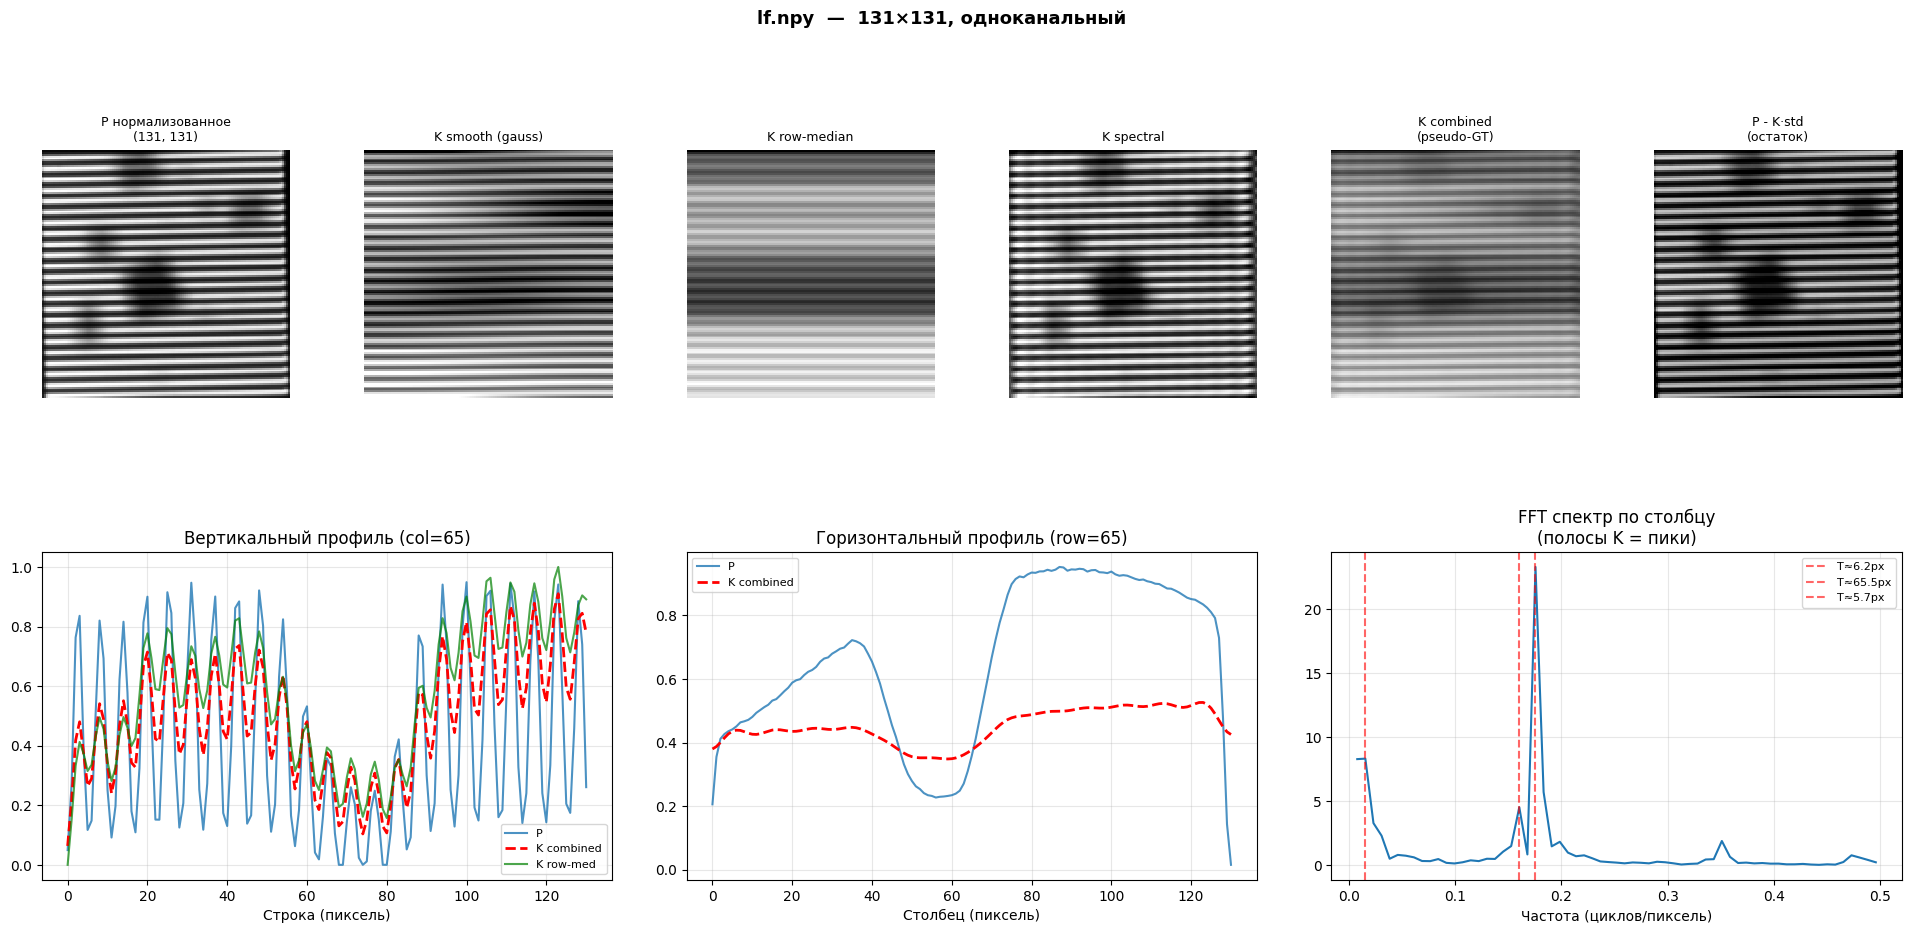

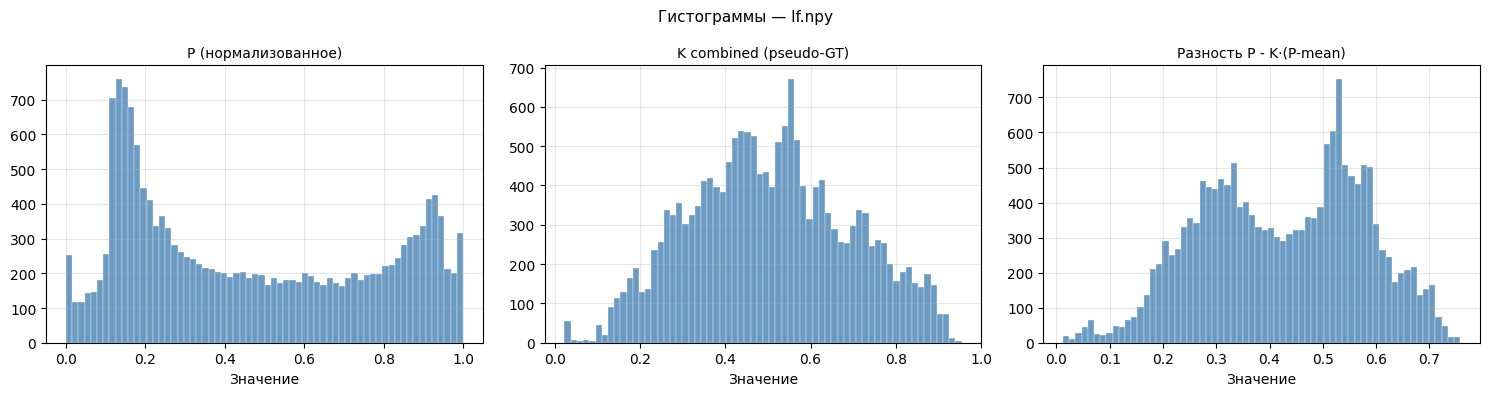

  ✓ P=torch.Size([1, 131, 131])  K=torch.Size([1, 131, 131])

Файл : lf2.npy
Shape: (131, 131)  dtype=float64
Range: [0.1858, 0.7550]  mean=0.4668  std=0.1678
После нормализации: [0.0000, 1.0000]


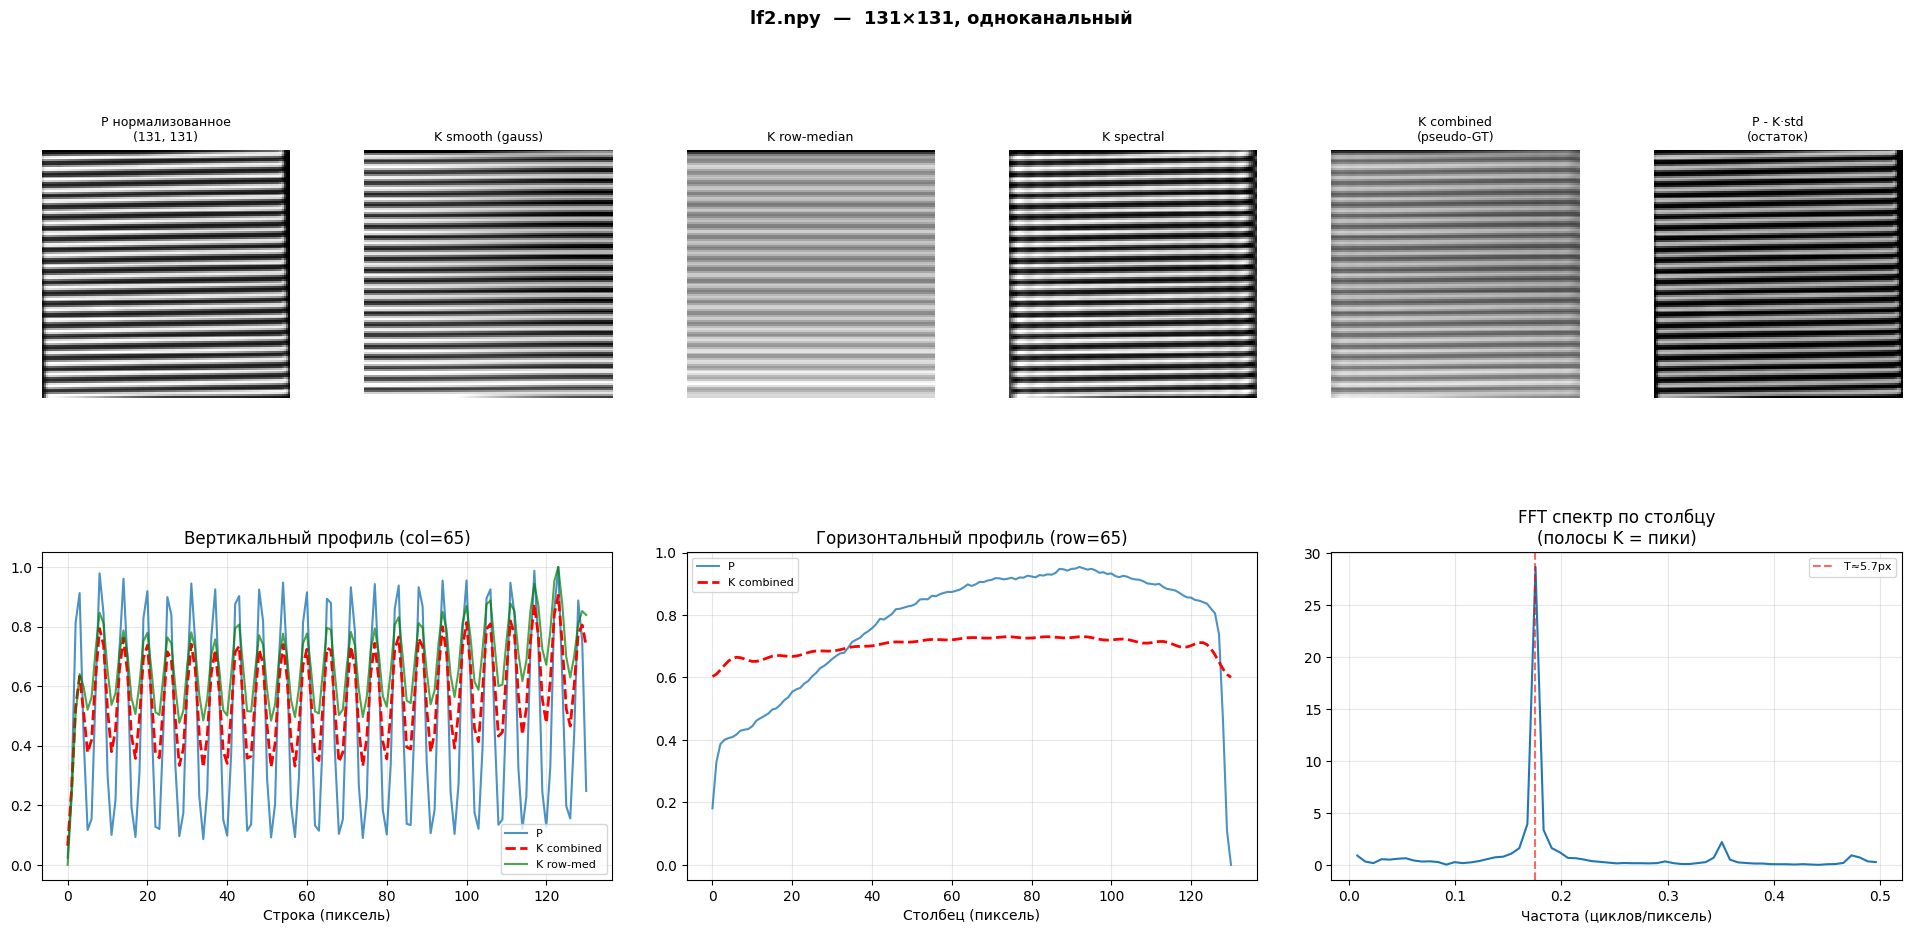

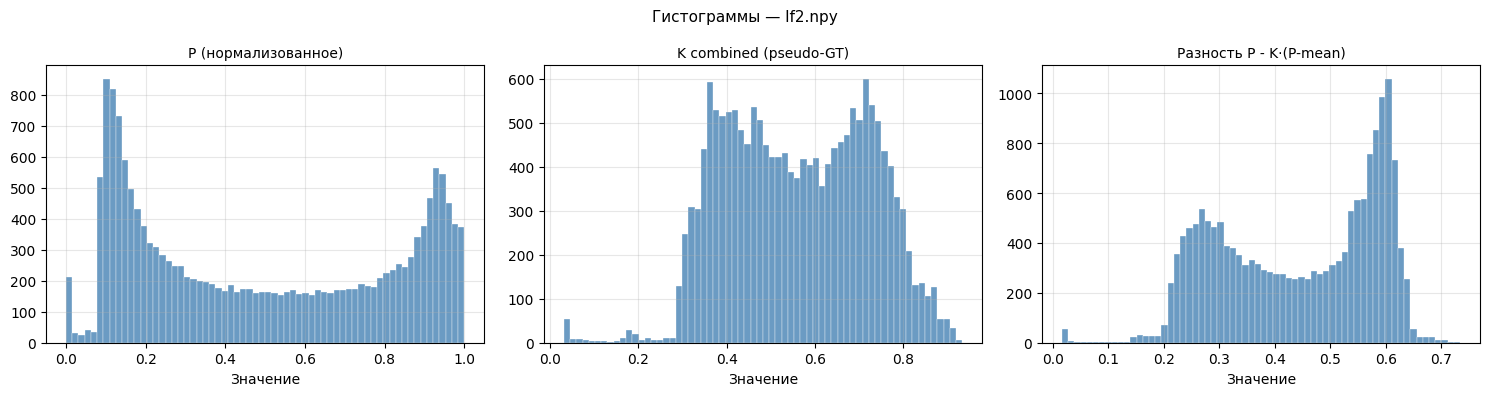

  ✓ P=torch.Size([1, 131, 131])  K=torch.Size([1, 131, 131])

Файл : lf3.npy
Shape: (131, 131)  dtype=float64
Range: [0.2184, 0.8180]  mean=0.4998  std=0.1705
После нормализации: [0.0000, 1.0000]


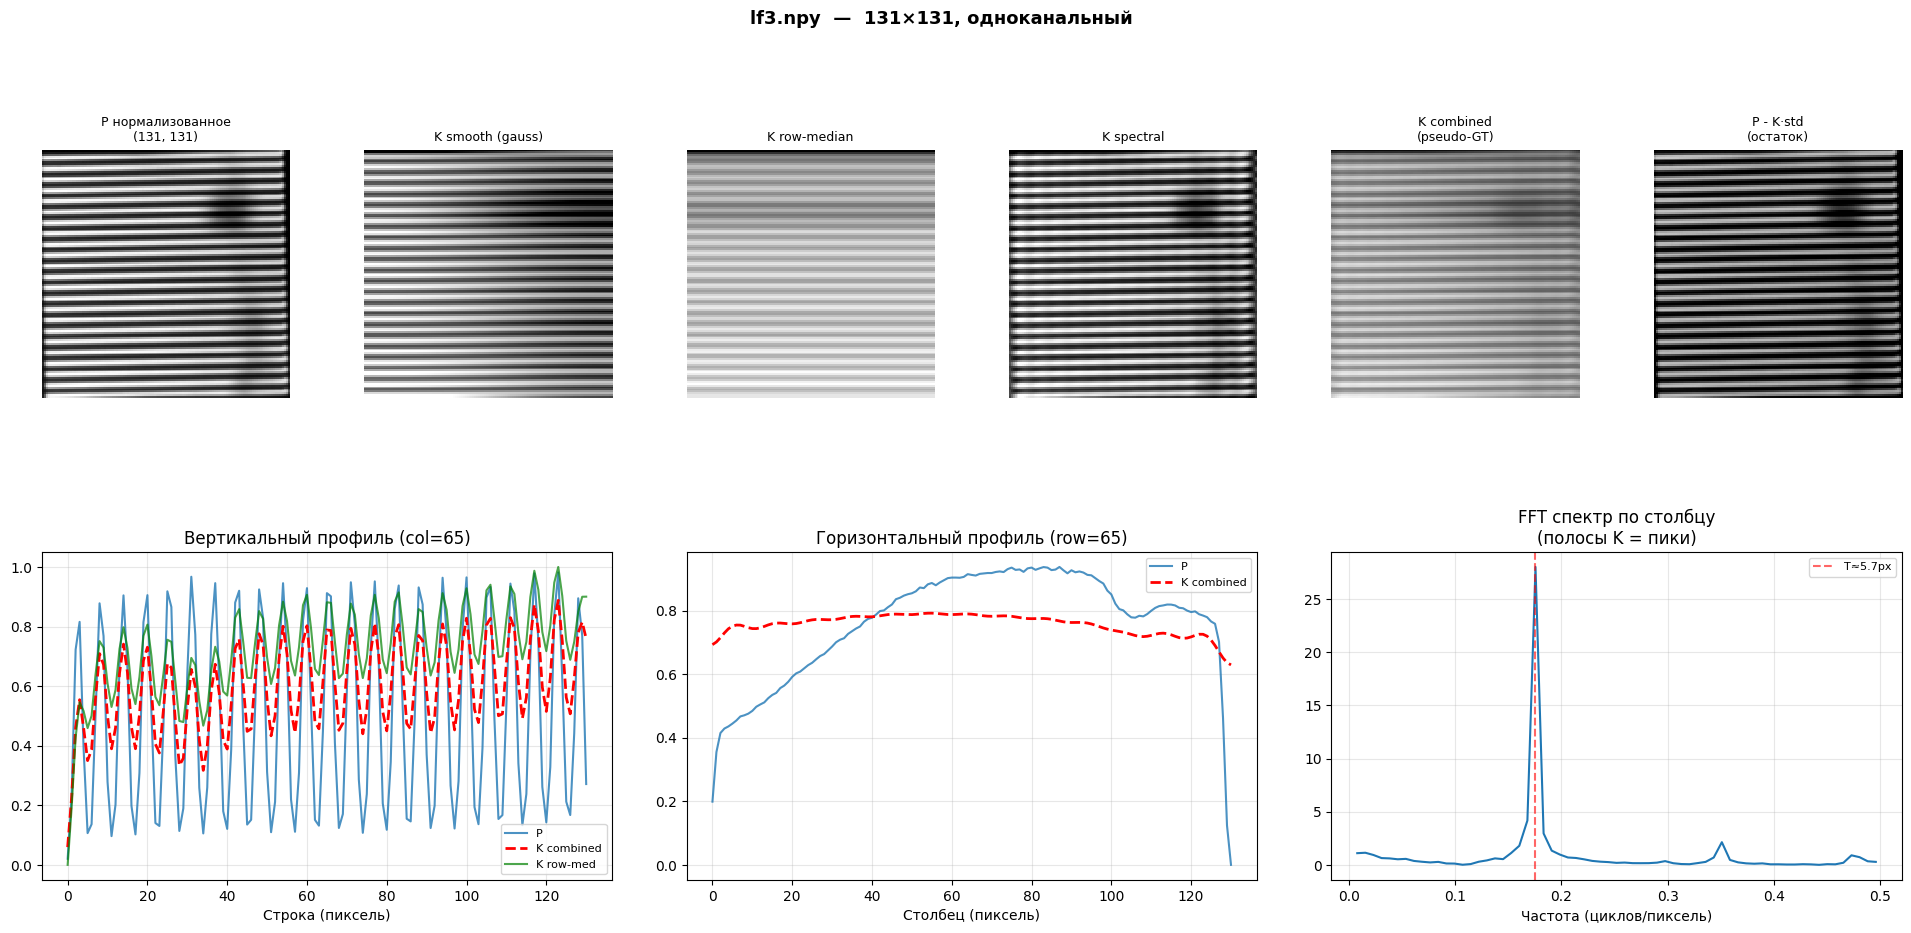

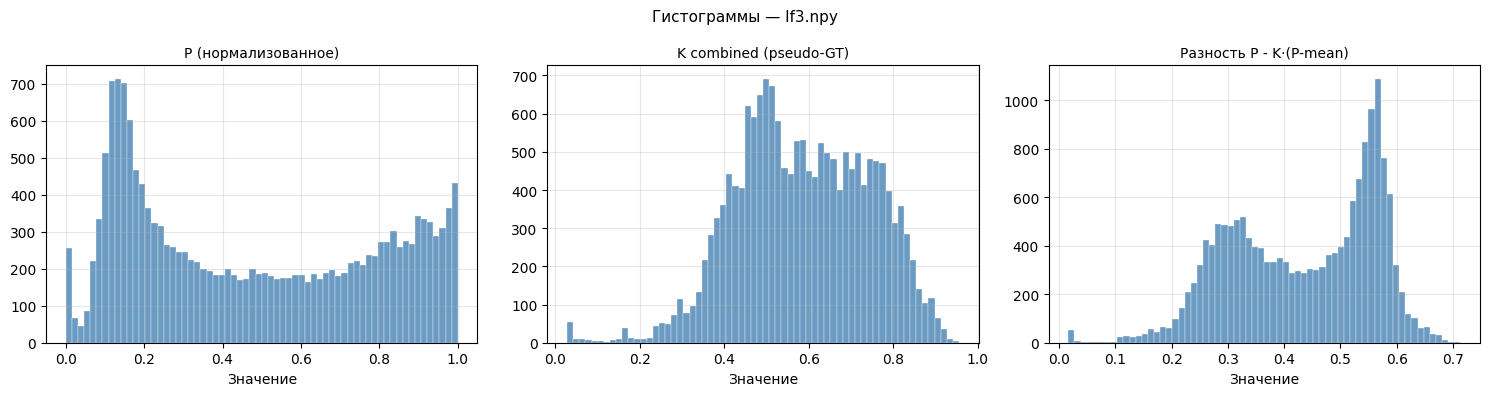

  ✓ P=torch.Size([1, 131, 131])  K=torch.Size([1, 131, 131])

Загружено 3 реальных примеров.
Размер снимков: 131×131, одноканальные.

  ВАЖНО: модель нужно переинициализировать с in_ch=1!
   В ячейке 10/13 используйте: KPredictor(in_ch=1, ...)
   В ячейке 8  используйте:    StripeDataset(..., n_channels=1)
   IMG_SIZE для синтетики можно оставить 512,
   но реальные снимки подаются в своём размере 131×131.


In [7]:
# Ячейка 7: Загрузка реальных файлов (одноканальные 131x131)

REAL_FILES   = ["lf.npy", "lf2.npy", "lf3.npy"]
DATA_DIR     = Path(".")
REAL_SAMPLES = []

# ── Важно: реальные снимки 131×131, одноканальные ──────────────────────────
# Мы НЕ масштабируем их до IMG_SIZE=512, чтобы не потерять структуру полос.
# Вместо этого используем их реальный размер.
# Модель будет одноканальной (in_ch=1).
REAL_SIZE = 131   # реальный размер снимков


def normalize_single(ch):
    """Нормализует одноканальный массив в [0, 1]."""
    ch = ch.astype(np.float32)
    # Уже в [0,1] диапазоне (min=0.16, max=0.79)
    if ch.max() > 2.0:
        ch = ch / 65535.0
    # Перцентильная нормализация — растягиваем контраст
    lo = np.percentile(ch, 1)
    hi = np.percentile(ch, 99)
    if hi - lo > 1e-6:
        ch = (ch - lo) / (hi - lo)
    ch = np.clip(ch, 0.0, 1.0)
    return ch.astype(np.float32)


def compute_K_for_small(p_np):
    """
    Вычисляет псевдо-GT маску K для маленького одноканального снимка.
    131×131 — полосы видны как горизонтальные вариации яркости.
    Используем несколько подходов и выбираем лучший.
    """
    h, w = p_np.shape

    # --- Метод 1: сглаживание по горизонтали ---
    # sigma_x большой (убирает контент), sigma_y маленький (сохраняет полосы)
    K1 = gaussian_filter(p_np, sigma=[1.5, w / 3.0])
    lo1, hi1 = np.percentile(K1, 2), np.percentile(K1, 98)
    if hi1 - lo1 > 1e-6:
        K1 = np.clip((K1 - lo1) / (hi1 - lo1), 0.0, 1.0)

    # --- Метод 2: медианное усреднение по строкам ---
    # Для каждой строки берём медиану — это убирает вертикальные объекты
    row_med = np.median(p_np, axis=1)          # [H]
    row_med = gaussian_filter(row_med, sigma=2.0)
    # Растягиваем в 2D
    K2 = np.tile(row_med[:, None], (1, w))     # [H, W]
    lo2, hi2 = K2.min(), K2.max()
    if hi2 - lo2 > 1e-6:
        K2 = np.clip((K2 - lo2) / (hi2 - lo2), 0.0, 1.0)

    # --- Метод 3: спектральный (оставляем только низкие частоты по X) ---
    fft_r = np.fft.rfft(p_np, axis=1)          # [H, W//2+1]
    freqs = np.fft.rfftfreq(w)
    # Пропускаем периоды > 10 пикселей (для 131px это разумно)
    cutoff = 1.0 / 10.0
    fft_r[:, freqs >= cutoff] = 0.0
    K3 = np.fft.irfft(fft_r, n=w, axis=1).astype(np.float32)
    lo3, hi3 = np.percentile(K3, 1), np.percentile(K3, 99)
    if hi3 - lo3 > 1e-6:
        K3 = np.clip((K3 - lo3) / (hi3 - lo3), 0.0, 1.0)

    # --- Взвешенное комбо ---
    K = 0.4 * K1 + 0.4 * K2 + 0.2 * K3
    K = gaussian_filter(K, sigma=[0.8, 0.3])
    K = np.clip(K, 0.0, 1.0)
    return K.astype(np.float32), K1.astype(np.float32), \
           K2.astype(np.float32), K3.astype(np.float32)


for fname in REAL_FILES:
    file_path = DATA_DIR / fname
    if not file_path.exists():
        print(f" {file_path} не найден, пропускаем.")
        continue

    p_np = np.load(file_path)
    print(f"\n{'='*55}")
    print(f"Файл : {fname}")
    print(f"Shape: {p_np.shape}  dtype={p_np.dtype}")
    print(f"Range: [{p_np.min():.4f}, {p_np.max():.4f}]  "
          f"mean={p_np.mean():.4f}  std={p_np.std():.4f}")

    # Убеждаемся, что 2D
    if p_np.ndim != 2:
        raise ValueError(f"Ожидали 2D, получили {p_np.ndim}D shape={p_np.shape}")

    # Нормализация
    p_norm = normalize_single(p_np)
    print(f"После нормализации: [{p_norm.min():.4f}, {p_norm.max():.4f}]")

    # Вычисляем K
    K_combined, K1, K2, K3 = compute_K_for_small(p_norm)

    # ── Визуализация ─────────────────────────────────────────────
    fig = plt.figure(figsize=(24, 10))
    gs  = fig.add_gridspec(2, 6, hspace=0.35, wspace=0.3)

    def ishow(ax, img, title, cmap='gray', vmin=0, vmax=1):
        ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax,
                  interpolation='nearest')
        ax.set_title(title, fontsize=9)
        ax.axis('off')

    # Верхний ряд — изображения
    ishow(fig.add_subplot(gs[0, 0]), p_norm,     f'P нормализованное\n{p_np.shape}')
    ishow(fig.add_subplot(gs[0, 1]), K1,          'K smooth (gauss)')
    ishow(fig.add_subplot(gs[0, 2]), K2,          'K row-median')
    ishow(fig.add_subplot(gs[0, 3]), K3,          'K spectral')
    ishow(fig.add_subplot(gs[0, 4]), K_combined,  'K combined\n(pseudo-GT)', vmin=0, vmax=1)

    # P - K (что останется после удаления полос)
    residual = np.clip(p_norm - K_combined * p_norm.std(), 0, 1)
    ishow(fig.add_subplot(gs[0, 5]), residual,    'P - K·std\n(остаток)')

    # Нижний ряд — профили
    h, w = p_norm.shape
    mid_col = w // 2
    mid_row = h // 2

    ax_v = fig.add_subplot(gs[1, 0:2])
    ax_v.plot(p_norm[:, mid_col],    label='P',          alpha=0.8, linewidth=1.5)
    ax_v.plot(K_combined[:, mid_col],label='K combined', color='red',
              linewidth=2, linestyle='--')
    ax_v.plot(K2[:, mid_col],        label='K row-med',  color='green',
              linewidth=1.5, alpha=0.7)
    ax_v.set_title(f'Вертикальный профиль (col={mid_col})')
    ax_v.legend(fontsize=8); ax_v.grid(True, alpha=0.3)
    ax_v.set_xlabel('Строка (пиксель)')

    ax_h = fig.add_subplot(gs[1, 2:4])
    ax_h.plot(p_norm[mid_row, :],     label='P',          alpha=0.8, linewidth=1.5)
    ax_h.plot(K_combined[mid_row, :], label='K combined', color='red',
              linewidth=2, linestyle='--')
    ax_h.set_title(f'Горизонтальный профиль (row={mid_row})')
    ax_h.legend(fontsize=8); ax_h.grid(True, alpha=0.3)
    ax_h.set_xlabel('Столбец (пиксель)')

    # FFT спектр по вертикали — видим период полос
    ax_f = fig.add_subplot(gs[1, 4:6])
    col_sig  = p_norm[:, mid_col]
    fft_mag  = np.abs(np.fft.rfft(col_sig))
    freqs_v  = np.fft.rfftfreq(len(col_sig))
    ax_f.plot(freqs_v[1:], fft_mag[1:], linewidth=1.5)
    ax_f.set_title('FFT спектр по столбцу\n(полосы K = пики)')
    ax_f.set_xlabel('Частота (циклов/пиксель)')
    ax_f.grid(True, alpha=0.3)
    # Топ-3 пика
    if len(fft_mag) > 3:
        peaks_idx, _ = find_peaks(fft_mag[1:],
                                  height=fft_mag[1:].max() * 0.15,
                                  distance=2)
        if len(peaks_idx) > 0:
            top = peaks_idx[np.argsort(fft_mag[1:][peaks_idx])[-3:]]
            for pk in top:
                f_pk = freqs_v[1:][pk]
                T_pk = 1.0 / f_pk if f_pk > 0 else 0
                ax_f.axvline(f_pk, color='red', alpha=0.6,
                             linestyle='--',
                             label=f'T≈{T_pk:.1f}px')
            ax_f.legend(fontsize=8)

    plt.suptitle(f'{fname}  —  131×131, одноканальный',
                 fontsize=13, fontweight='bold')
    plt.show()

    # ── Гистограммы ──────────────────────────────────────────────
    fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
    for ax, data, title in zip(
        axes2,
        [p_norm, K_combined, p_norm - K_combined * (p_norm - p_norm.mean())],
        ['P (нормализованное)', 'K combined (pseudo-GT)', 'Разность P - K·(P-mean)']
    ):
        ax.hist(data.ravel(), bins=64, color='steelblue', alpha=0.8,
                edgecolor='white', linewidth=0.3)
        ax.set_title(title, fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('Значение')
    plt.suptitle(f'Гистограммы — {fname}', fontsize=11)
    plt.tight_layout()
    plt.show()

    # ── Сохраняем (размер 131×131, одноканальный) ─────────────────
    # P_tensor: [1, 131, 131]  — один канал
    # K_tensor: [1, 131, 131]
    P_tensor = torch.from_numpy(p_norm).float().unsqueeze(0)       # [1, H, W]
    K_tensor = torch.from_numpy(K_combined).float().unsqueeze(0)   # [1, H, W]

    REAL_SAMPLES.append({
        "P":     P_tensor,
        "K":     K_tensor,
        "fname": fname,
        "size":  (h, w),
    })
    print(f"  ✓ P={P_tensor.shape}  K={K_tensor.shape}")

print(f"\n{'='*55}")
print(f"Загружено {len(REAL_SAMPLES)} реальных примеров.")
print(f"Размер снимков: {REAL_SIZE}×{REAL_SIZE}, одноканальные.")
print()
print("  ВАЖНО: модель нужно переинициализировать с in_ch=1!")
print("   В ячейке 10/13 используйте: KPredictor(in_ch=1, ...)")
print("   В ячейке 8  используйте:    StripeDataset(..., n_channels=1)")
print("   IMG_SIZE для синтетики можно оставить 512,")
print("   но реальные снимки подаются в своём размере 131×131.")

In [9]:
# Ячейка 8: Датасеты

class StripeDataset(Dataset):
    def __init__(self, paths, augment=False):
        self.paths   = paths
        self.augment = augment
        self._rng    = np.random.default_rng(1337)

    def __len__(self):
        return len(self.paths)

    def _augment_arrays(self, arrays):
        if self._rng.random() > 0.5:
            arrays = [np.fliplr(a).copy() for a in arrays]
        if self._rng.random() > 0.5:
            arrays = [np.flipud(a).copy() for a in arrays]
        if self._rng.random() > 0.3:
            k = int(self._rng.integers(1, 4))
            arrays = [np.rot90(a, k).copy() for a in arrays]
        return arrays

    def __getitem__(self, idx):
        o_np, f_np = load_image_channels(self.paths[idx])
        H, W = o_np.shape
        K_np = make_realistic_K(H, W, rng=self._rng)

        if self.augment:
            o_np, f_np, K_np = self._augment_arrays([o_np, f_np, K_np])

        alpha = float(self._rng.uniform(0.5, 1.3))
        beta  = float(self._rng.uniform(0.1, 0.9))
        bias  = float(self._rng.uniform(-0.02, 0.02))

        # ОДНОКАНАЛЬНОЕ изображение
        P_np = np.clip(alpha * K_np * o_np + beta * (1 - K_np) * f_np + bias, 0, 1)
        noise = self._rng.normal(0, SIGMA_NOISE, (H, W)).astype(np.float32)
        P_np = np.clip(P_np + noise, 0, 1)

        return {
            "P":       torch.from_numpy(P_np[None]).float(),  # [1, H, W]
            "K":       torch.from_numpy(K_np[None]).float(),  # [1, H, W]
            "o":       torch.from_numpy(o_np[None]).float(),
            "f":       torch.from_numpy(f_np[None]).float(),
            "weight":  torch.tensor(1.0),
            "is_real": torch.tensor(False),
        }


class CombinedDataset(Dataset):
    def __init__(self, synthetic_ds, real_samples, augment_real=True):
        self.synthetic    = synthetic_ds
        self.real_samples = real_samples
        self.augment_real = augment_real
        self.syn_len      = len(synthetic_ds)
        self.real_len     = len(real_samples)
        self._rng         = np.random.default_rng(42)

    def __len__(self):
        return self.syn_len + self.real_len

    def __getitem__(self, idx):
        if idx < self.syn_len:
            item = self.synthetic[idx]
            item['weight']  = torch.tensor(1.0)
            item['is_real'] = torch.tensor(False)
            return item

        real_idx = (idx - self.syn_len) % self.real_len
        sample   = self.real_samples[real_idx]
        P = sample["P"].clone()  # [1, 131, 131]
        K = sample["K"].clone()  # [1, 131, 131]

        # Ресайз к размеру синтетики (IMG_SIZE x IMG_SIZE)
        P = F.interpolate(P.unsqueeze(0), size=(IMG_SIZE, IMG_SIZE), 
                         mode='bilinear', align_corners=False).squeeze(0)
        K = F.interpolate(K.unsqueeze(0), size=(IMG_SIZE, IMG_SIZE), 
                         mode='bilinear', align_corners=False).squeeze(0)

        if self.augment_real:
            if self._rng.random() > 0.5:
                P = torch.flip(P, dims=[2])
                K = torch.flip(K, dims=[2])
            if self._rng.random() > 0.5:
                P = torch.flip(P, dims=[1])
                K = torch.flip(K, dims=[1])
            if self._rng.random() > 0.3:
                k = int(self._rng.integers(1, 4))
                P = torch.rot90(P, k, dims=[1, 2])
                K = torch.rot90(K, k, dims=[1, 2])
            brightness = float(self._rng.uniform(0.85, 1.15))
            P = torch.clamp(P * brightness, 0, 1)

        # Для реальных данных o, f не нужны (используем dummy)
        dummy = torch.zeros_like(P)
        return {
            "P":       P,           # [1, IMG_SIZE, IMG_SIZE]
            "K":       K,           # [1, IMG_SIZE, IMG_SIZE]
            "o":       dummy,       # заглушка
            "f":       dummy,       # заглушка
            "weight":  torch.tensor(20.0),  # высокий вес для реальных
            "is_real": torch.tensor(True),
        }

In [10]:
# Ячейка 9: Сэмплер с гарантированным включением реальных примеров


class BalancedBatchSampler(Sampler):
    def __init__(self, dataset, batch_size, n_real_per_batch=1, seed=42):
        self.syn_len     = dataset.syn_len
        self.real_len    = dataset.real_len
        self.real_offset = dataset.syn_len
        self.batch_size  = batch_size
        self.n_real      = min(n_real_per_batch, batch_size - 1)
        self.n_syn       = batch_size - self.n_real
        self.rng         = np.random.default_rng(seed)

    def __iter__(self):
        syn_idx = self.rng.permutation(self.syn_len)
        ptr = 0
        while ptr + self.n_syn <= len(syn_idx):
            batch_syn  = syn_idx[ptr: ptr + self.n_syn].tolist()
            batch_real = (self.real_offset +
                          self.rng.integers(0, self.real_len,
                                            size=self.n_real)).tolist()
            batch = batch_syn + batch_real
            self.rng.shuffle(batch)
            yield batch
            ptr += self.n_syn

    def __len__(self):
        return self.syn_len // self.n_syn

In [11]:
# Ячейка 10: Архитектура сети с gradient checkpointing
# ИСПРАВЛЕНО:
# 1) модель теперь одноканальная: in_ch=1
# 2) тестовый dummy_in тоже одноканальный
# 3) тест делаем в eval()+no_grad(), чтобы не жрал лишнюю память
# 4) тестируем на размере 131x131, как у реальных данных

class ChannelAttention(nn.Module):
    def __init__(self, ch, reduction=8):
        super().__init__()
        mid = max(ch // reduction, 4)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(ch, mid),
            nn.ReLU(inplace=True),
            nn.Linear(mid, ch),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c = x.shape[:2]
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w


class ResBlock(nn.Module):
    def __init__(self, ch, dropout=0.05):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.GroupNorm(min(8, ch), ch),
            nn.GELU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.GroupNorm(min(8, ch), ch),
        )
        self.ca = ChannelAttention(ch)

    def _inner(self, x):
        return F.gelu(x + self.ca(self.net(x)))

    def forward(self, x):
        # checkpointing только в train-режиме
        if self.training:
            return checkpoint_grad.checkpoint(self._inner, x, use_reentrant=False)
        return self._inner(x)


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, n_res=1, dropout=0.05):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.GELU(),
            *[ResBlock(out_ch, dropout) for _ in range(n_res)],
        )
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.conv(x)
        return self.pool(x), x


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, n_res=1, dropout=0.05):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.GELU(),
            *[ResBlock(out_ch, dropout) for _ in range(n_res)],
        )

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class KPredictor(nn.Module):
    """
    Одноканальный U-Net:
    вход  [B, 1, H, W]
    выход [B, 1, H, W]
    """
    def __init__(self, in_ch=1, base_ch=32, dropout=0.05):
        super().__init__()
        b = base_ch

        self.d1 = DownBlock(in_ch, b,    n_res=1, dropout=dropout)
        self.d2 = DownBlock(b,    b*2,   n_res=1, dropout=dropout)
        self.d3 = DownBlock(b*2,  b*4,   n_res=1, dropout=dropout)
        self.d4 = DownBlock(b*4,  b*8,   n_res=1, dropout=dropout)

        self.bot = nn.Sequential(
            ResBlock(b*8, dropout),
            ChannelAttention(b*8),
        )

        self.u4 = UpBlock(b*8, b*8, b*4, n_res=1, dropout=dropout)
        self.u3 = UpBlock(b*4, b*4, b*2, n_res=1, dropout=dropout)
        self.u2 = UpBlock(b*2, b*2, b,   n_res=1, dropout=dropout)
        self.u1 = UpBlock(b,   b,   b,   n_res=1, dropout=dropout)

        self.head = nn.Sequential(
            nn.Conv2d(b, b // 2, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(b // 2, 1, 1),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.GroupNorm, nn.BatchNorm2d)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, P):
        x, s1 = self.d1(P)
        x, s2 = self.d2(x)
        x, s3 = self.d3(x)
        x, s4 = self.d4(x)

        x = self.bot(x)

        x = self.u4(x, s4)
        x = self.u3(x, s3)
        x = self.u2(x, s2)
        x = self.u1(x, s1)

        return torch.sigmoid(self.head(x))


# --- Проверка модели и памяти ---
torch.cuda.empty_cache()

model_core_test = KPredictor(in_ch=1, base_ch=32, dropout=0.05).to(DEVICE)

if USE_MULTI_GPU:
    model_test = nn.DataParallel(model_core_test, device_ids=GPU_IDS)
    print(f"DataParallel активен на GPU: {GPU_IDS}")
else:
    model_test = model_core_test
    print(f"Single GPU режим: {DEVICE}")

# Тест делаем на реальном размере 131x131 и с 1 каналом
test_h = 131
test_w = 131
test_bs = max(2, len(GPU_IDS)) if USE_MULTI_GPU else 2

model_test.eval()
with torch.no_grad():
    dummy_in = torch.randn(test_bs, 1, test_h, test_w, device=DEVICE)
    dummy_out = model_test(dummy_in)

print(f"Тест forward: {dummy_in.shape} -> {dummy_out.shape}")

params = sum(p.numel() for p in model_core_test.parameters() if p.requires_grad)
print(f"Параметров: {params:,}")

for i in GPU_IDS:
    if i < torch.cuda.device_count():
        alloc = torch.cuda.memory_allocated(i) / 1e9
        reserv = torch.cuda.memory_reserved(i) / 1e9
        print(f"  GPU {i}: allocated={alloc:.2f}GB, reserved={reserv:.2f}GB")

del model_test, model_core_test, dummy_in, dummy_out
torch.cuda.empty_cache()

DataParallel активен на GPU: [0, 1]
Тест forward: torch.Size([2, 1, 131, 131]) -> torch.Size([2, 1, 131, 131])
Параметров: 4,386,301
  GPU 0: allocated=0.03GB, reserved=0.07GB
  GPU 1: allocated=0.01GB, reserved=0.06GB


/home/user/.local/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


In [15]:
# Ячейка 11: Функции потерь 

def gradient_loss(pred, target):
    def sobel_x(x):
        k = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]],
                          dtype=x.dtype, device=x.device).view(1,1,3,3)
        return F.conv2d(x, k, padding=1)

    def sobel_y(x):
        k = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]],
                          dtype=x.dtype, device=x.device).view(1,1,3,3)
        return F.conv2d(x, k, padding=1)

    return (F.l1_loss(sobel_x(pred), sobel_x(target)) +
            F.l1_loss(sobel_y(pred), sobel_y(target)))


def frequency_loss(pred, target):
    """Безопасная версия с проверками на NaN/Inf"""
    # Конвертируем в float32 для стабильности
    pred = pred.float()
    target = target.float()
    
    pred_fft = torch.fft.rfft2(pred)
    tgt_fft  = torch.fft.rfft2(target)
    
    # Амплитуды с большим eps
    pred_amp = torch.abs(pred_fft) + 1e-6
    tgt_amp  = torch.abs(tgt_fft)  + 1e-6
    
    # Клиппинг перед логарифмом
    pred_amp = torch.clamp(pred_amp, min=1e-6, max=1e6)
    tgt_amp  = torch.clamp(tgt_amp,  min=1e-6, max=1e6)
    
    # Логарифм с защитой
    loss = F.l1_loss(torch.log(pred_amp + 1e-8), torch.log(tgt_amp + 1e-8))
    
    # Проверка на NaN
    if torch.isnan(loss) or torch.isinf(loss):
        return torch.tensor(0.0, device=pred.device)
    
    return loss


def stripe_consistency_loss(K_hat):
    """Полосы горизонтальны — штраф за большой градиент по X"""
    diff_x = K_hat[:, :, :, 1:] - K_hat[:, :, :, :-1]
    loss = diff_x.abs().mean()
    
    if torch.isnan(loss):
        return torch.tensor(0.0, device=K_hat.device)
    
    return loss


def total_loss_fn(K_hat, K_gt, weight, o=None, f=None, P=None,
                  phys_model=None, is_real=None):
    """
    K_hat, K_gt : [B, 1, H, W]
    weight       : [B]
    """
    B = K_hat.shape[0]
    weight = weight.view(B)

    # Базовый L1
    l1 = F.l1_loss(K_hat, K_gt, reduction='none').mean(dim=[1, 2, 3])
    
    # Gradient loss (поэлементно)
    l_grad_list = []
    for i in range(B):
        gl = gradient_loss(K_hat[i:i+1], K_gt[i:i+1])
        if torch.isnan(gl) or torch.isinf(gl):
            gl = torch.tensor(0.0, device=K_hat.device)
        l_grad_list.append(gl)
    l_grad = torch.stack(l_grad_list)
    
    # Frequency loss (поэлементно)
    l_freq_list = []
    for i in range(B):
        fl = frequency_loss(K_hat[i:i+1], K_gt[i:i+1])
        l_freq_list.append(fl)
    l_freq = torch.stack(l_freq_list)

    # Взвешенная сумма
    sup_loss = (weight * (W_L1 * l1 + W_GRAD * l_grad + W_FREQ * l_freq)).mean()

    # Регуляризация
    reg_stripe = stripe_consistency_loss(K_hat)

    # Физический loss (ТОЛЬКО для синтетики одного размера)
    phys_loss = torch.tensor(0.0, device=K_hat.device)
    if (phys_model is not None and is_real is not None 
        and o is not None and P is not None):
        mask_syn = ~is_real
        if mask_syn.any():
            try:
                pm = (phys_model.module if hasattr(phys_model, 'module') 
                      else phys_model)
                P_pred = pm(o[mask_syn], f[mask_syn], K_hat[mask_syn])
                phys_loss = F.mse_loss(P_pred, P[mask_syn])
                
                if torch.isnan(phys_loss) or torch.isinf(phys_loss):
                    phys_loss = torch.tensor(0.0, device=K_hat.device)
            except:
                phys_loss = torch.tensor(0.0, device=K_hat.device)

    total = sup_loss + 0.05 * reg_stripe + W_PHYS * phys_loss
    
    # Финальная проверка
    if torch.isnan(total) or torch.isinf(total):
        print(" NaN detected in total loss! Using fallback.")
        total = F.l1_loss(K_hat, K_gt)

    return total, {
        'l1':         l1.mean().item(),
        'grad':       l_grad.mean().item(),
        'freq':       l_freq.mean().item(),
        'stripe_reg': reg_stripe.item(),
        'phys':       phys_loss.item(),
    }

In [13]:
# Ячейка 12: Создание датасетов и DataLoader



REAL_SAMPLES_CPU = [
    {"P": s["P"].cpu(), "K": s["K"].cpu(), "fname": s["fname"]}
    for s in REAL_SAMPLES
]

syn_train_ds = StripeDataset(train_paths, augment=True)
syn_val_ds   = StripeDataset(val_paths,   augment=False)

combined_train_ds = CombinedDataset(syn_train_ds, REAL_SAMPLES_CPU, augment_real=True)
combined_val_ds   = CombinedDataset(syn_val_ds,   REAL_SAMPLES_CPU, augment_real=False)

n_real_per_batch = max(1, BATCH_SIZE // 4)
batch_sampler = BalancedBatchSampler(
    combined_train_ds,
    batch_size=BATCH_SIZE,
    n_real_per_batch=n_real_per_batch,
    seed=42,
)

train_dl = DataLoader(
    combined_train_ds,
    batch_sampler=batch_sampler,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True,
)
val_dl = DataLoader(
    combined_val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
)

print(f"Train batches/epoch: {len(train_dl)}")
print(f"Val   batches:       {len(val_dl)}")
print(f"Реальных/батч (train): {n_real_per_batch}")

Train batches/epoch: 742
Val   batches:       99
Реальных/батч (train): 1


In [ ]:
# Ячейка 13: Инициализация и обучение с DataParallel

torch.cuda.empty_cache()

# --- Физическая модель (только на основном GPU, небольшая) ---
phys_model = PhysicsModel().to(DEVICE)

# --- Основная модель ---
_model_core = KPredictor(in_ch=1, base_ch=32, dropout=0.05).to(DEVICE)

# DataParallel: автоматически разбивает батч между GPU
if USE_MULTI_GPU:
    model = nn.DataParallel(_model_core, device_ids=GPU_IDS)
    print(f"DataParallel: GPU {GPU_IDS}, batch={BATCH_SIZE} "
          f"({BATCH_SIZE // len(GPU_IDS)} per GPU)")
else:
    model = _model_core
    print(f"Single GPU: {DEVICE}")

# --- Оптимизатор ---
# DataParallel: параметры берём из .module
model_params = (_model_core.parameters()
                if USE_MULTI_GPU else model.parameters())

optimizer = torch.optim.AdamW([
    {'params': model_params,             'lr': LR,       'weight_decay': 1e-4},
    {'params': phys_model.parameters(), 'lr': LR * 0.1, 'weight_decay': 0.0},
], betas=(0.9, 0.999))

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=15, T_mult=2, eta_min=1e-6
)

# Mixed precision scaler
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

history = {k: [] for k in
           ["train_loss", "val_loss", "train_l1", "val_l1",
            "train_grad", "val_grad"]}
best_val_loss = float("inf")
best_epoch    = 0

total_params = sum(p.numel() for p in _model_core.parameters()
                   if p.requires_grad)
print(f"Параметров модели: {total_params:,}")
print(f"Gradient accumulation steps: {ACCUM_STEPS}")
print(f"Effective batch size: {BATCH_SIZE * ACCUM_STEPS}")
print("=" * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    # ==================== TRAIN ====================
    model.train()
    phys_model.train()
    running = {k: 0.0 for k in
               ["loss", "l1", "grad", "freq", "stripe_reg", "phys"]}
    n_batches = 0

    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(train_dl,
                desc=f"E{epoch:03d}/{NUM_EPOCHS} [train]",
                dynamic_ncols=True)

    for step, batch in enumerate(pbar):
        P       = batch["P"].to(DEVICE, non_blocking=True)
        K_gt    = batch["K"].to(DEVICE, non_blocking=True)
        o       = batch["o"].to(DEVICE, non_blocking=True)
        f       = batch["f"].to(DEVICE, non_blocking=True)
        weight  = batch["weight"].float().to(DEVICE, non_blocking=True)
        is_real = batch["is_real"].to(DEVICE)

        with torch.cuda.amp.autocast(enabled=False):  # ← ВЫКЛЮЧАЕМ AMP
            K_hat = model(P)
            loss, parts = total_loss_fn(
                K_hat, K_gt, weight,
                o=o, f=f, P=P,
                phys_model=phys_model,
                is_real=is_real,
            )
            # Нормируем на число шагов накопления
            loss_scaled = loss / ACCUM_STEPS

        scaler.scale(loss_scaled).backward()

        # Обновляем веса каждые ACCUM_STEPS шагов
        if (step + 1) % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                _model_core.parameters(), max_norm=1.0)
            torch.nn.utils.clip_grad_norm_(
                phys_model.parameters(), max_norm=0.5)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        for k, v in parts.items():
            running[k] = running.get(k, 0.0) + v
        running["loss"] += loss.item()
        n_batches += 1

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "l1":   f"{parts['l1']:.4f}",
            "phys": f"{parts['phys']:.4f}",
        })

    # Финальный шаг если батчи не кратны ACCUM_STEPS
    if n_batches % ACCUM_STEPS != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(_model_core.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    scheduler.step(epoch - 1)

    avg_train = {k: v / max(n_batches, 1) for k, v in running.items()}
    history["train_loss"].append(avg_train["loss"])
    history["train_l1"].append(avg_train["l1"])
    history["train_grad"].append(avg_train["grad"])

    # ==================== VALIDATION ====================
    model.eval()
    phys_model.eval()
    val_run = {"loss": 0.0, "l1": 0.0, "grad": 0.0}
    n_val   = 0

    with torch.no_grad():
        for batch in tqdm(val_dl,
                          desc=f"E{epoch:03d}/{NUM_EPOCHS} [val]",
                          leave=False, dynamic_ncols=True):
            P       = batch["P"].to(DEVICE, non_blocking=True)
            K_gt    = batch["K"].to(DEVICE, non_blocking=True)
            o       = batch["o"].to(DEVICE, non_blocking=True)
            f       = batch["f"].to(DEVICE, non_blocking=True)
            weight  = batch["weight"].float().to(DEVICE, non_blocking=True)
            is_real = batch["is_real"].to(DEVICE)

            with torch.cuda.amp.autocast(
                    enabled=torch.cuda.is_available()):
                K_hat = model(P)
                loss, parts = total_loss_fn(
                    K_hat, K_gt, weight,
                    o=o, f=f, P=P,
                    phys_model=phys_model,
                    is_real=is_real,
                )

            val_run["loss"] += loss.item()
            val_run["l1"]   += parts["l1"]
            val_run["grad"] += parts["grad"]
            n_val += 1

    avg_val = {k: v / max(n_val, 1) for k, v in val_run.items()}
    history["val_loss"].append(avg_val["loss"])
    history["val_l1"].append(avg_val["l1"])
    history["val_grad"].append(avg_val["grad"])

    # Сохранение (всегда сохраняем .module для DataParallel)
    if avg_val["loss"] < best_val_loss:
        best_val_loss = avg_val["loss"]
        best_epoch    = epoch
        core = _model_core  # уже без DataParallel wrapper
        torch.save({
            "epoch":            epoch,
            "model_state_dict": core.state_dict(),
            "phys_state_dict":  phys_model.state_dict(),
            "optimizer_state":  optimizer.state_dict(),
            "val_loss":         best_val_loss,
        }, SAVE_PATH)
        saved = " Сохранена"
    else:
        saved = ""

    # Память GPU
    mem_info = []
    for gi in GPU_IDS:
        if gi < torch.cuda.device_count():
            a = torch.cuda.memory_allocated(gi) / 1e9
            r = torch.cuda.memory_reserved(gi) / 1e9
            mem_info.append(f"G{gi}:{a:.1f}/{r:.1f}GB")

    lr_now = optimizer.param_groups[0]["lr"]
    print(
        f"E{epoch:03d} | "
        f"tr={avg_train['loss']:.4f}(l1={avg_train['l1']:.3f}) | "
        f"val={avg_val['loss']:.4f}(l1={avg_val['l1']:.3f}) | "
        f"lr={lr_now:.1e} | "
        f"{' '.join(mem_info)}"
        f"{saved}"
    )

print(f"\nГотово. Лучшая модель: epoch={best_epoch}, "
      f"val_loss={best_val_loss:.4f}")

DataParallel: GPU [0, 1], batch=4 (2 per GPU)
Параметров модели: 4,386,301
Gradient accumulation steps: 2
Effective batch size: 8





E001/60 [train]:   0%|                                  | 0/742 [00:00<?, ?it/s]


E001/60 [train]:   0%| | 0/742 [00:03<?, ?it/s, loss=9.4205, l1=0.3456, phys=0.0


E001/60 [train]:   0%| | 1/742 [00:03<46:46,  3.79s/it, loss=9.4205, l1=0.3456, 


E001/60 [train]:   0%| | 1/742 [00:04<46:46,  3.79s/it, loss=10.0642, l1=0.3867,


E001/60 [train]:   0%| | 2/742 [00:04<21:11,  1.72s/it, loss=10.0642, l1=0.3867,


E001/60 [train]:   0%| | 2/742 [00:04<21:11,  1.72s/it, loss=8.8612, l1=0.3847, 


E001/60 [train]:   0%| | 3/742 [00:04<12:46,  1.04s/it, loss=8.8612, l1=0.3847, 


E001/60 [train]:   0%| | 3/742 [00:04<12:46,  1.04s/it, loss=8.8155, l1=0.3629, 


E001/60 [train]:   1%| | 4/742 [00:04<08:58,  1.37it/s, loss=8.8155, l1=0.3629, 


E001/60 [train]:   1%| | 4/742 [00:05<08:58,  1.37it/s, loss=8.4253, l1=0.4274, 


E001/60 [train]:   1%| | 5/742 [00:05<10:23,  1.18it/s, loss=8.4253, l1=0.4274, 


E001/60 [train]:   1%| | 5/742 [00:05<10:23,  1.18it/s, loss=8.3937, l1=0.4126, 


E

In [27]:


REAL_SAMPLES_CPU = [
    {"P": s["P"].cpu(), "K": s["K"].cpu(), "fname": s["fname"]}
    for s in REAL_SAMPLES
]

syn_train_ds = StripeDataset(train_paths, augment=True)
syn_val_ds   = StripeDataset(val_paths,   augment=False)

combined_train_ds = CombinedDataset(syn_train_ds, REAL_SAMPLES_CPU, augment_real=True)
combined_val_ds   = CombinedDataset(syn_val_ds,   REAL_SAMPLES_CPU, augment_real=False)

n_real_per_batch = max(1, BATCH_SIZE // 4)
batch_sampler = BalancedBatchSampler(
    combined_train_ds,
    batch_size=BATCH_SIZE,
    n_real_per_batch=n_real_per_batch,
    seed=42,
)

# ← ОТКЛЮЧАЕМ WORKERS (num_workers=0)
train_dl = DataLoader(
    combined_train_ds,
    batch_sampler=batch_sampler,
    num_workers=4,        # ← БЫЛО 4
    pin_memory=False,     # ← БЫЛО True
    # prefetch_factor убираем при num_workers=0
    # persistent_workers убираем
)

val_dl = DataLoader(
    combined_val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,        # ← БЫЛО 4
    pin_memory=False,     # ← БЫЛО True
)

print(f"Train batches/epoch: {len(train_dl)}")
print(f"Val   batches:       {len(val_dl)}")
print(f"Реальных/батч (train): {n_real_per_batch}")
print("\n⚠️  ОТЛАДОЧНЫЙ РЕЖИМ: num_workers=0")

Train batches/epoch: 742
Val   batches:       99
Реальных/батч (train): 1

⚠️  ОТЛАДОЧНЫЙ РЕЖИМ: num_workers=0
